# DockQ follow-up: pooling, weighting and fine-tuning

Analyze 36 jobs plus three reused controls: 3 evaluation-only diagnostics, 24 new pooling runs and 9 fine-tunes. All comparisons use the same frozen validation cohort and seeds 7, 17 and 27. The main endpoint is ordinary graph-average validation DockQ MSE. Training predictions are evaluated with dropout disabled, making train/validation comparisons more interpretable than training-mode histories.

Error bars show sample standard deviation across seeds, **not confidence intervals**. Selecting a configuration on these ten validation targets does not establish test generalization. No test predictions or model checkpoint tensors are loaded. Figures use large Computer Modern text, full borders and no titles.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
GATE=Path.cwd() if (Path.cwd()/'dockq_followup_sweep').is_dir() else Path.cwd()/'gate_run'
ROOT=GATE/'dockq_followup_sweep'; EXPORT=GATE/'dockq_followup_analysis'; EXPORT.mkdir(exist_ok=True)
matrix=json.loads((ROOT/'matrix.json').read_text())
SEEDS=[7,17,27]; POOLS=['all','interface','combined']; ALPHAS=[.5,.75,1.]
POOL_LABEL={'all':'Whole graph','interface':'Interface only','combined':'Combined'}
EDGES=np.array([0,.2,.4,.6,.8,1],dtype=np.float32)
BIN_LABELS=['0--0.2','0.2--0.4','0.4--0.6','0.6--0.8','0.8--1.0']
mpl.rcParams.update({'text.usetex':True,'font.family':'serif','font.serif':['Computer Modern Roman'],
 'mathtext.fontset':'cm','axes.labelsize':23,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':17,
 'axes.spines.top':True,'axes.spines.right':True,'axes.linewidth':1.1})
def save(fig,name):
    fig.savefig(EXPORT/(name+'.pdf'),bbox_inches='tight')
    fig.savefig(EXPORT/(name+'.png'),dpi=180,bbox_inches='tight'); plt.show()
def get_frame(path):
    f=pd.read_csv(path).sort_values(['target_id','graph_name']).reset_index(drop=True)
    assert not f.duplicated(['target_id','graph_name']).any(), path
    assert np.isfinite(f[['true_target','predicted_target']]).all().all()
    assert f.true_target.between(0,1).all()
    return f
def spearman(g):
    return float(spearmanr(g.true_target,g.predicted_target).statistic) if g.true_target.nunique()>1 and g.predicted_target.nunique()>1 else np.nan

## Completion, cohort and checkpoint audit

Require complete expected epoch histories, finite losses, identical graph keys/labels within each split, and disjoint training/validation targets. Reused controls are checked against the new diagnostic predictions. Fine-tuning selection includes epoch zero: the selected epoch is zero when the starting checkpoint beats every subsequent epoch. Epoch zero is not present in the training loss CSV, so it must be included explicitly.

In [2]:
assert matrix['validation_only'] and len(matrix['runs'])==36 and len(matrix['reused_controls'])==3
split=json.loads((GATE/'model_extensions_10pct_quick_no_apbs'/'target_splits.json').read_text())['splits']
refs={}; frames={}; histories={}; records=[]; bins=[]; targets=[]; seen=set(); profiles=[]
for run in matrix['runs']:
    cfg=run['followup']; stage=cfg['stage']; seed=run['seed']; path=ROOT/Path(run['output']).name
    pool=cfg['pooling']; alpha=cfg['exponent']; lam=cfg['reconstruction_lambda']
    key=(stage,pool,alpha,lam,seed); assert key not in seen;seen.add(key)
    argv=run['argv']; assert '--no-test-evaluation' in argv
    assert argv[argv.index('--checkpoint-metric')+1]=='target_mse'
    base=dict(run=path.name,stage=stage,pool=pool,alpha=alpha,lam=lam,seed=seed)
    row=dict(base); ff={}
    for name,manifest_name in [('training','train'),('validation','val')]:
        f=get_frame(path/(name+'_predictions.csv'));ff[name]=f
        assert len(f)==split[manifest_name]['sample_count']
        assert set(f.target_id)==set(split[manifest_name]['targets'])
        identity=f[['target_id','graph_name','true_target']]
        if name not in refs: refs[name]=identity
        else: pd.testing.assert_frame_equal(refs[name],identity)
        e=f.predicted_target-f.true_target;row[name+'_mse']=np.mean(e**2)
        b=np.searchsorted(EDGES[1:-1],f.true_target.to_numpy(dtype=np.float32),side='right')
        for i in range(5):
            g=f.loc[b==i];err=g.predicted_target-g.true_target
            bins.append(dict(**base,split=name,bin=i,n=len(g),mse=np.mean(err**2),bias=err.mean(),observed=g.true_target.mean(),predicted=g.predicted_target.mean()))
        for t,g in f.groupby('target_id'):
            targets.append(dict(**base,split=name,target=t,n=len(g),mse=np.mean((g.predicted_target-g.true_target)**2),rho=spearman(g)))
    assert not set(ff['training'].target_id)&set(ff['validation'].target_id)
    profile=json.loads((path/'dockq_training_distribution.json').read_text());profiles.append(profile)
    assert profile['counts']==profiles[0]['counts'] and sum(profile['counts'])==len(refs['training'])
    assert profile['exponent']==alpha
    frames[key]=ff
    if stage!='diagnostic':
        assert (path/'gate_model.pt').exists()
        h=pd.read_csv(path/'loss_history.csv'); expected=20 if stage=='finetune' else 50
        assert h.epoch.tolist()==list(range(1,expected+1))
        assert np.isfinite(h.filter(regex='^(train_|val_)').to_numpy()).all()
        assert h.filter(regex='^test_').isna().all().all()
        assert np.allclose(h.weight_node_mse,lam) and np.allclose(h.weight_target_mse,1)
        best=h.loc[h.val_target_mse.idxmin()]; chosen_mse=best.val_target_mse; chosen_epoch=int(best.epoch)
        row.update(epochs=len(h),final_mse=h.iloc[-1].val_target_mse,lowest_new_mse=best.val_target_mse)
        if stage=='finetune':
            initial=json.loads((path/'initial_validation.json').read_text())['pooled_mse'];row['initial_mse']=initial
            if initial<=chosen_mse:chosen_mse=initial;chosen_epoch=0
        row['selected_epoch']=chosen_epoch
        assert np.isclose(chosen_mse,row['validation_mse'],rtol=1e-4,atol=1e-7)
        histories[key]=h
    records.append(row)
assert len(seen)==36
metrics=pd.DataFrame(records);per_bin=pd.DataFrame(bins);per_target=pd.DataFrame(targets)
control=metrics.loc[metrics.stage=='diagnostic'].set_index('seed')
assert sorted(control.index)==SEEDS
for c in matrix['reused_controls']:
    f=get_frame(GATE/'dockq_priority_sweep'/Path(c['output']).name/'validation_predictions.csv')
    current=frames['diagnostic','all',.5,1,c['seed']]['validation']
    pd.testing.assert_frame_equal(f[['target_id','graph_name','true_target']],current[['target_id','graph_name','true_target']])
    np.testing.assert_allclose(f.predicted_target,current.predicted_target,rtol=1e-4,atol=1e-6)
for r in metrics.loc[metrics.stage=='finetune'].itertuples():
    assert np.isclose(r.initial_mse,control.loc[r.seed,'validation_mse'],rtol=1e-4,atol=1e-7)
metrics['delta_control']=metrics.validation_mse-metrics.seed.map(control.validation_mse)
agg=per_target.loc[per_target.split=='validation'].groupby('run').agg(macro_mse=('mse','mean'),macro_rho=('rho','mean'),defined_rho=('rho','count'))
metrics=metrics.join(agg,on='run').join(per_bin.loc[per_bin.split=='validation'].groupby('run').mse.mean().rename('bin_mse'),on='run')
for name,f in [('per_run',metrics),('per_target',per_target),('per_bin',per_bin)]:f.to_csv(EXPORT/(name+'.csv'),index=False)
print(f'PASS: 36 completed jobs, 3 reused controls verified; {len(refs["training"])} training and {len(refs["validation"])} validation graphs.')
print(f'{refs["training"].target_id.nunique()} training targets; {refs["validation"].target_id.nunique()} validation targets. No test predictions read.')

PASS: 36 completed jobs, 3 reused controls verified; 10910 training and 1132 validation graphs.
90 training targets; 10 validation targets. No test predictions read.


## Pooling and weighting: matched three-seed results

Diagnostic re-evaluation supplies the reused whole-graph, α=0.5 control. The exponent α increases training-label frequency weighting while its cap stays fixed. All pooling arms use reconstruction λ=1, dropout 0.3 and 50 epochs. Combined pooling concatenates whole-graph and interface mean/max summaries and increases the graph-projector input width; its effect is not isolated from the additional parameters.

n  mean_mse   sd_mse  train_mse  macro_mse  macro_rho  \
pool      alpha                                                          
combined  0.75   3   0.06967  0.00167    0.05643    0.06762    0.48687   
          0.50   3   0.07158  0.00080    0.05142    0.06958    0.47093   
          1.00   3   0.07196  0.00188    0.05985    0.06985    0.46342   
all       0.50   3   0.07339  0.00229    0.05332    0.07159    0.42764   
          1.00   3   0.07356  0.00227    0.04871    0.07180    0.44493   
          0.75   3   0.07434  0.00091    0.05937    0.07246    0.43777   
interface 0.50   3   0.07509  0.00215    0.06021    0.07248    0.44676   
          0.75   3   0.07846  0.00087    0.06760    0.07575    0.43620   
          1.00   3   0.07850  0.00151    0.06507    0.07546    0.43930   

                 bin_mse  improvement_pct  
pool      alpha                            
combined  0.75   0.08180          5.05850  
          0.50   0.08916          2.46367  
          1.00   0.08143          1.94355  
all       0.50   0.09138          0.00000  
          1.00   0.09012         -0.23116  
          0.75   0.08589         -1.30476  
interface 0.50   0.08520         -2.31483  
          0.75   0.08678         -6.90580  
          1.00   0.08857         -6.97235

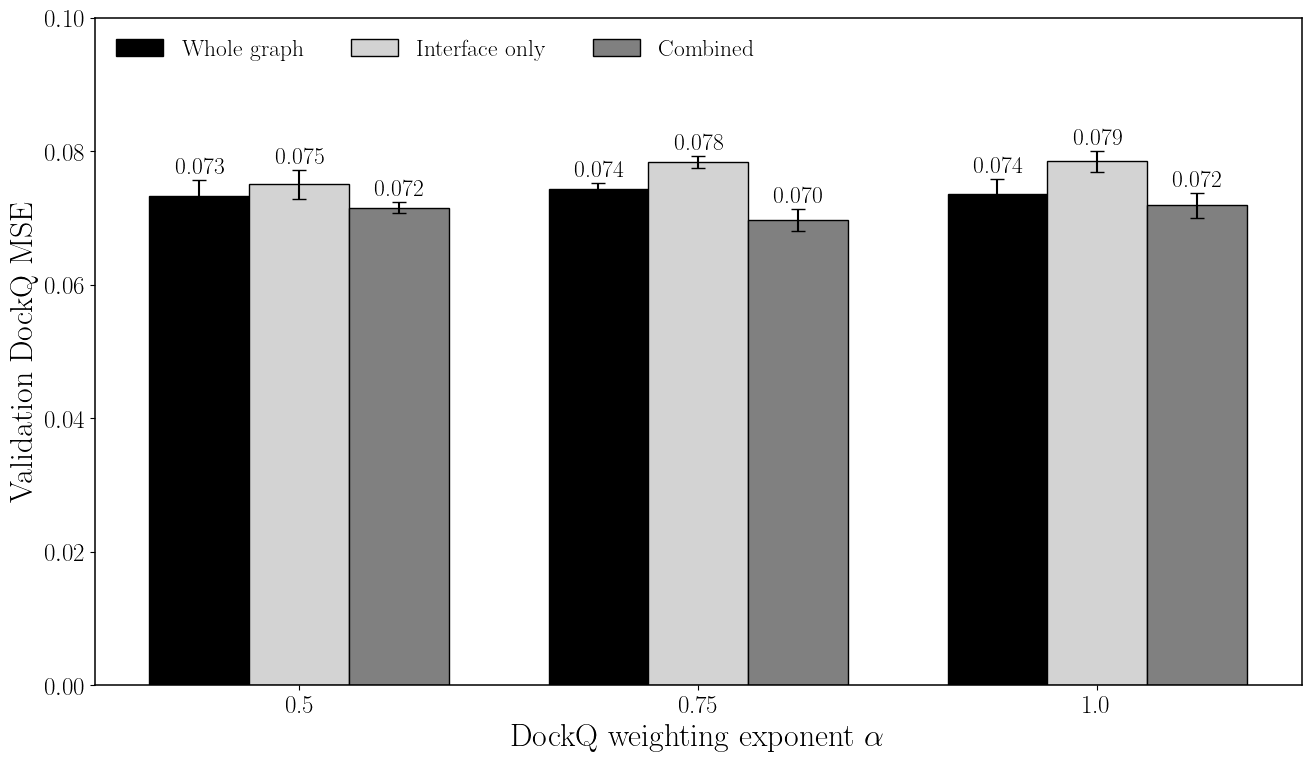

In [3]:
pooling=metrics.loc[metrics.stage.isin(['pooling','diagnostic'])].copy()
summary=pooling.groupby(['pool','alpha']).agg(n=('seed','nunique'),mean_mse=('validation_mse','mean'),sd_mse=('validation_mse','std'),
 train_mse=('training_mse','mean'),macro_mse=('macro_mse','mean'),macro_rho=('macro_rho','mean'),bin_mse=('bin_mse','mean'))
assert len(summary)==9 and summary.n.eq(3).all()
CONTROL=('all',.5);WINNER=summary.mean_mse.idxmin()
summary['improvement_pct']=100*(1-summary.mean_mse/summary.loc[CONTROL,'mean_mse'])
summary.to_csv(EXPORT/'pooling_summary.csv');display(summary.sort_values('mean_mse').round(5))
fig,ax=plt.subplots(figsize=(13,7.5),constrained_layout=True)
x=np.arange(3);width=.25
for j,(pool,color) in enumerate(zip(POOLS,['black','lightgray','gray'])):
    tab=summary.loc[pool].loc[ALPHAS];positions=x+(j-1)*width
    ax.bar(positions,tab.mean_mse,width,yerr=tab.sd_mse,color=color,edgecolor='black',capsize=5,label=POOL_LABEL[pool])
    for pos,m,sd in zip(positions,tab.mean_mse,tab.sd_mse):ax.text(pos,m+sd+.001,f'{m:.3f}',ha='center',fontsize=17)
ax.set_xticks(x,['0.5','0.75','1.0']);ax.set_xlabel(r'DockQ weighting exponent $\alpha$');ax.set_ylabel('Validation DockQ MSE')
ax.set_ylim(0,.10);ax.legend(frameon=False,ncol=3,loc='upper left');save(fig,'pooling_weighting_mse')

## Paired seeds and target variation

Compare the validation-selected setting with the previous best within each seed. Target comparisons average each target's MSE over seeds. These descriptive comparisons use the same validation set that selected the configuration; they are not independent confirmation.

,validation_mse,training_mse,delta_control,selected_epoch
seed,,,,
7,0.07124,0.05944,-0.00212,7.0
17,0.06791,0.06122,-0.00320,9.0
27,0.06987,0.04864,-0.00582,23.0


,control,selected,delta
target,,,
1kac,0.10360,0.08979,-0.01381
2vdb,0.09573,0.08281,-0.01292
2grn,0.10976,0.09866,-0.01110
1zhi,0.09522,0.08539,-0.00983
1us7,0.03390,0.03069,-0.00321
1j2j,0.07430,0.07364,-0.00066
1ugq,0.05819,0.05757,-0.00062
7bxh,0.05891,0.05886,-0.00005
1ay7,0.06403,0.06857,0.00454


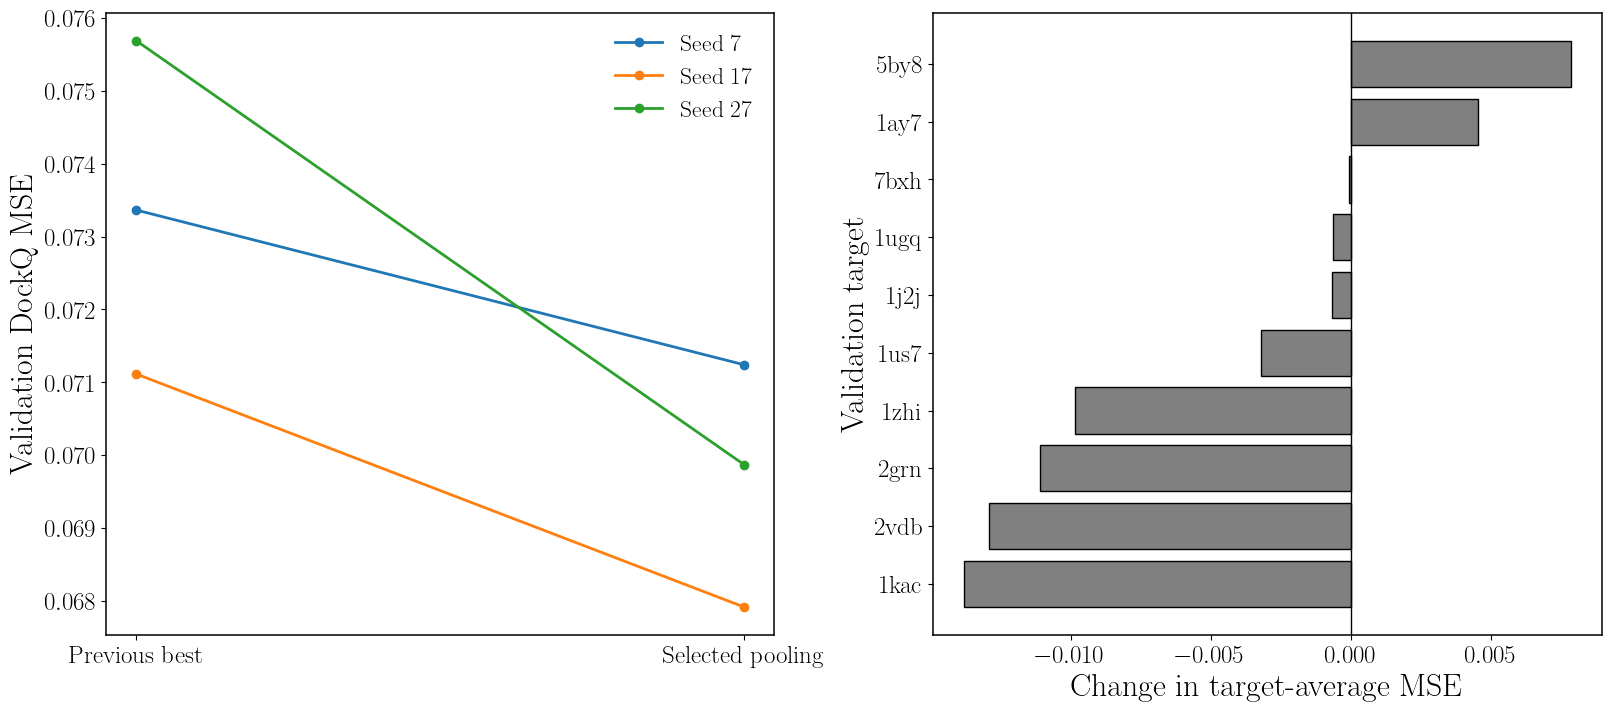

In [4]:
selected=pooling.loc[(pooling.pool==WINNER[0])&(pooling.alpha==WINNER[1])].set_index('seed')
display(selected[['validation_mse','training_mse','delta_control','selected_epoch']].round(5))
pt=per_target.loc[per_target.split=='validation']
base_pt=pt.loc[pt.stage=='diagnostic'].groupby('target').mse.mean()
win_pt=pt.loc[(pt.stage=='pooling')&(pt.pool==WINNER[0])&(pt.alpha==WINNER[1])].groupby('target').mse.mean()
target_comparison=pd.DataFrame({'control':base_pt,'selected':win_pt});target_comparison['delta']=target_comparison.selected-target_comparison.control
target_comparison.to_csv(EXPORT/'target_comparison.csv');display(target_comparison.sort_values('delta').round(5))
fig,axes=plt.subplots(1,2,figsize=(16,7),constrained_layout=True)
for seed in SEEDS:
    axes[0].plot([0,1],[control.loc[seed,'validation_mse'],selected.loc[seed,'validation_mse']],'o-',lw=2,label=f'Seed {seed}')
axes[0].set_xticks([0,1],['Previous best','Selected pooling']);axes[0].set_ylabel('Validation DockQ MSE');axes[0].legend(frameon=False)
positions=np.arange(len(target_comparison));ordered=target_comparison.sort_values('delta')
axes[1].barh(positions,ordered.delta,color='gray',edgecolor='black');axes[1].set_yticks(positions,ordered.index)
axes[1].axvline(0,color='black',lw=1);axes[1].set_xlabel('Change in target-average MSE');axes[1].set_ylabel('Validation target')
save(fig,'paired_seed_target_changes')

## Is high-DockQ compression already present in training?

Both splits below use evaluation mode at the selected checkpoint. Training and validation contain different targets and different score distributions; a gap alone cannot identify its cause. Bin-wise comparisons help separate score-range effects. The table also shows whether high-DockQ examples are available across many training targets.

,bin,graphs,targets_with_examples,largest_target_share
0,0,5116,90,0.0141
1,1,1693,90,0.0219
2,2,1345,90,0.0245
3,3,1389,87,0.0202
4,4,1367,85,0.0271


mse    bias  observed  predicted     n
split      bin                                           
training   0    0.0590  0.2056    0.0565     0.2621  5116
           1    0.0265  0.0924    0.2957     0.3882  1693
           2    0.0172 -0.0093    0.4931     0.4838  1345
           3    0.0503 -0.1758    0.7091     0.5332  1389
           4    0.1038 -0.2964    0.8638     0.5674  1367
validation 0    0.0490  0.1772    0.0525     0.2297   539
           1    0.0299  0.0002    0.2926     0.2928   172
           2    0.0498 -0.1276    0.4959     0.3683   131
           3    0.1138 -0.2815    0.7084     0.4269   171
           4    0.2143 -0.4236    0.8644     0.4407   119

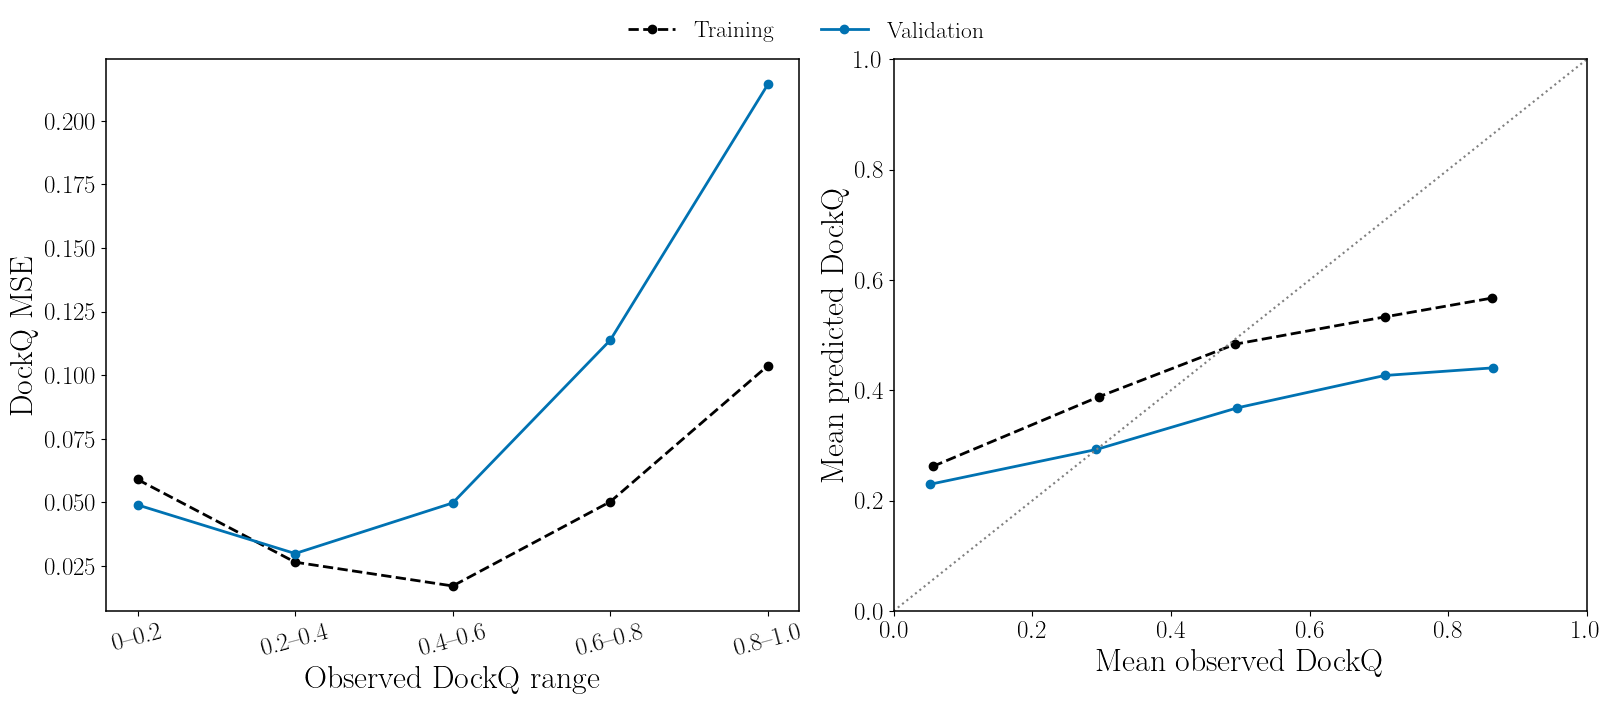

In [5]:
diag_bins=per_bin.loc[per_bin.stage=='diagnostic'].groupby(['split','bin']).agg(mse=('mse','mean'),bias=('bias','mean'),observed=('observed','mean'),predicted=('predicted','mean'),n=('n','first'))
coverage=refs['training'].copy();coverage['bin']=np.searchsorted(EDGES[1:-1],coverage.true_target.to_numpy(dtype=np.float32),side='right')
counts=pd.crosstab(coverage.target_id,coverage['bin']).reindex(columns=range(5),fill_value=0)
counts.to_csv(EXPORT/'training_target_coverage.csv')
coverage_summary=pd.DataFrame({'bin':range(5),'graphs':counts.sum().values,'targets_with_examples':(counts>0).sum().values,'largest_target_share':counts.max().values/counts.sum().values})
display(coverage_summary.round(4));display(diag_bins.round(4))
fig,axes=plt.subplots(1,2,figsize=(16,7),constrained_layout=True)
for split_name,color,ls in [('training','black','--'),('validation','#0072B2','-')]:
    tab=diag_bins.loc[split_name]
    axes[0].plot(range(5),tab.mse,'o'+ls,color=color,lw=2,label=split_name.capitalize())
    axes[1].plot(tab.observed,tab.predicted,'o'+ls,color=color,lw=2,label=split_name.capitalize())
axes[0].set_xticks(range(5),BIN_LABELS,rotation=15);axes[0].set_xlabel('Observed DockQ range');axes[0].set_ylabel('DockQ MSE')
axes[1].plot([0,1],[0,1],ls=':',color='gray');axes[1].set_xlim(0,1);axes[1].set_ylim(0,1)
axes[1].set_xlabel('Mean observed DockQ');axes[1].set_ylabel('Mean predicted DockQ')
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=2,frameon=False);save(fig,'training_validation_diagnostic')

## Does the selected pooling setting improve the whole range?

Compare the previous best and the selected pooling configuration on the identical validation graphs. Bias is predicted minus observed DockQ. The contribution table weights each bin's MSE change by its graph count, decomposing the pooled-MSE improvement without implying causation.

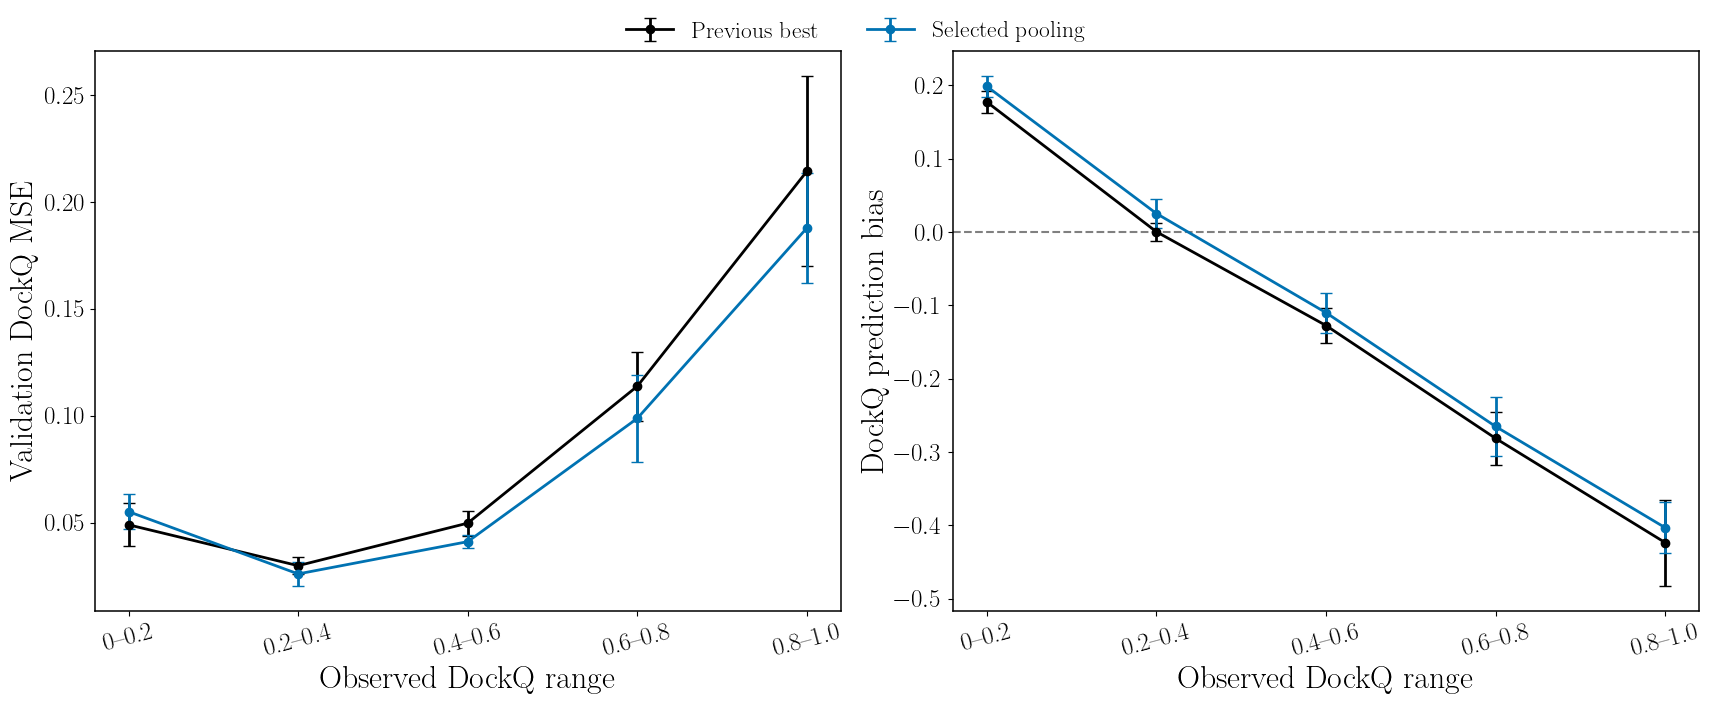

,mse,bias,predicted,observed,n,control_mse,contribution
bin,,,,,,,
0,0.05520,0.19846,0.25097,0.05252,539,0.04904,-0.00293
1,0.02608,0.02510,0.31772,0.29262,172,0.02993,0.00058
2,0.04116,-0.11009,0.38585,0.49594,131,0.04982,0.00100
3,0.09879,-0.26527,0.44313,0.70840,171,0.11381,0.00227
4,0.18779,-0.40326,0.46111,0.86437,119,0.21432,0.00279


In [6]:
new_bins=per_bin.loc[(per_bin.stage=='pooling')&(per_bin.pool==WINNER[0])&(per_bin.alpha==WINNER[1])&(per_bin.split=='validation')]
old_bins=per_bin.loc[(per_bin.stage=='diagnostic')&(per_bin.split=='validation')]
fig,axes=plt.subplots(1,2,figsize=(17,7),constrained_layout=True)
for f,label,color in [(old_bins,'Previous best','black'),(new_bins,'Selected pooling','#0072B2')]:
    for ax,col,ylabel in zip(axes,['mse','bias'],['Validation DockQ MSE','DockQ prediction bias']):
        tab=f.groupby('bin')[col].agg(['mean','std']);ax.errorbar(range(5),tab['mean'],yerr=tab['std'],color=color,marker='o',lw=2,capsize=4,label=label)
        ax.set_xticks(range(5),BIN_LABELS,rotation=15);ax.set_xlabel('Observed DockQ range');ax.set_ylabel(ylabel)
axes[1].axhline(0,ls='--',color='gray');fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=2,frameon=False)
save(fig,'validation_range_accuracy')
ranges=new_bins.groupby('bin').agg(mse=('mse','mean'),bias=('bias','mean'),predicted=('predicted','mean'),observed=('observed','mean'),n=('n','first'))
ranges['control_mse']=old_bins.groupby('bin').mse.mean()
ranges['contribution']=(ranges.control_mse-ranges.mse)*ranges.n/ranges.n.sum()
assert np.isclose(ranges.contribution.sum(),summary.loc[CONTROL,'mean_mse']-summary.loc[WINNER,'mean_mse'])
ranges.to_csv(EXPORT/'selected_range_comparison.csv');display(ranges.round(5))

## Fine-tuning: account for the starting checkpoint

All three reconstruction weights receive 20 additional epochs at the same reduced learning rate, initialized from the same selected checkpoint within each seed. λ=1 is the continued-training control. Epoch zero is eligible for selection. Identical exported predictions can therefore mean all runs retained their starting model, rather than training failing to execute.

,seed,lam,epochs,initial_mse,lowest_new_mse,selected_epoch,validation_mse,final_mse
27,7,0.0,20.0,0.073363,0.078250,0.0,0.073363,0.088216
28,7,0.1,20.0,0.073363,0.077707,0.0,0.073363,0.085897
29,7,1.0,20.0,0.073363,0.077160,0.0,0.073363,0.082373
30,17,0.0,20.0,0.071112,0.075089,0.0,0.071112,0.076480
31,17,0.1,20.0,0.071112,0.075165,0.0,0.071112,0.075658
32,17,1.0,20.0,0.071112,0.074317,0.0,0.071112,0.074663
33,27,0.0,20.0,0.075687,0.076258,0.0,0.075687,0.079490
34,27,0.1,20.0,0.075687,0.076110,0.0,0.075687,0.080610
35,27,1.0,20.0,0.075687,0.076107,0.0,0.075687,0.078799


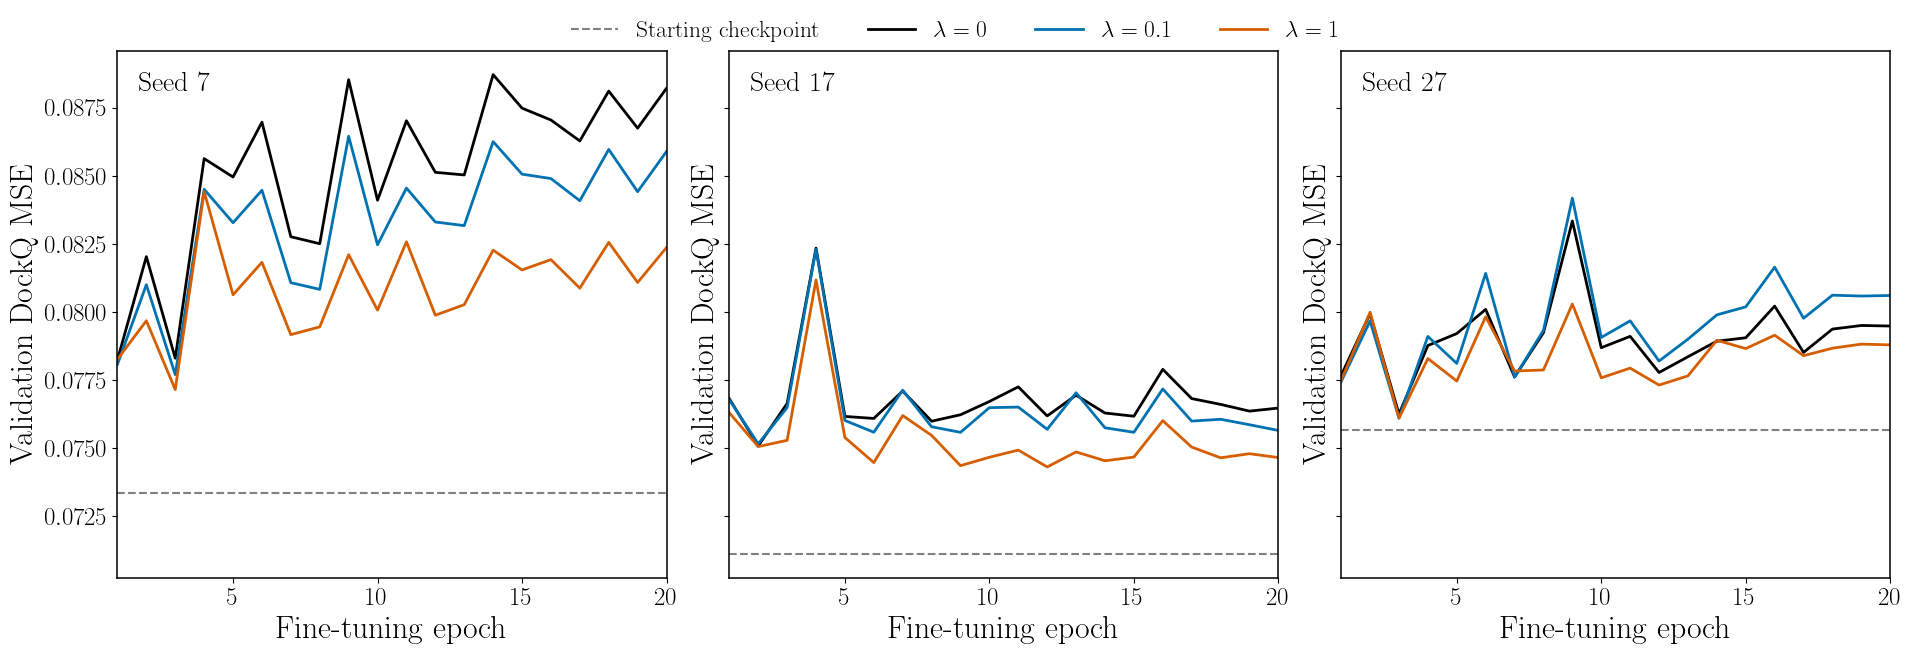

In [7]:
fine=metrics.loc[metrics.stage=='finetune'].copy()
fine['new_minus_initial']=fine.lowest_new_mse-fine.initial_mse
fine.to_csv(EXPORT/'finetuning.csv',index=False)
display(fine[['seed','lam','epochs','initial_mse','lowest_new_mse','selected_epoch','validation_mse','final_mse']].round(6))
fig,axes=plt.subplots(1,3,figsize=(19,6.5),sharey=True,constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.axhline(control.loc[seed,'validation_mse'],color='gray',ls='--',label='Starting checkpoint')
    for lam,color in [(0,'black'),(.1,'#0072B2'),(1,'#D55E00')]:
        h=histories['finetune','all',.5,lam,seed];ax.plot(h.epoch,h.val_target_mse,color=color,lw=2,label=rf'$\lambda={lam:g}$')
    ax.text(.04,.96,f'Seed {seed}',transform=ax.transAxes,va='top',fontsize=20)
    ax.set_xlabel('Fine-tuning epoch');ax.set_ylabel('Validation DockQ MSE');ax.set_xlim(1,20)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=4,frameon=False);save(fig,'finetuning_validation')

## Convergence of the pooling candidates

Curves average ordinary validation MSE across seeds; shading shows seed standard deviation. The original whole-graph control history is read from the preceding sweep. The selected configuration and its same-exponent interface-only comparison are trained from scratch with equal epoch budgets.

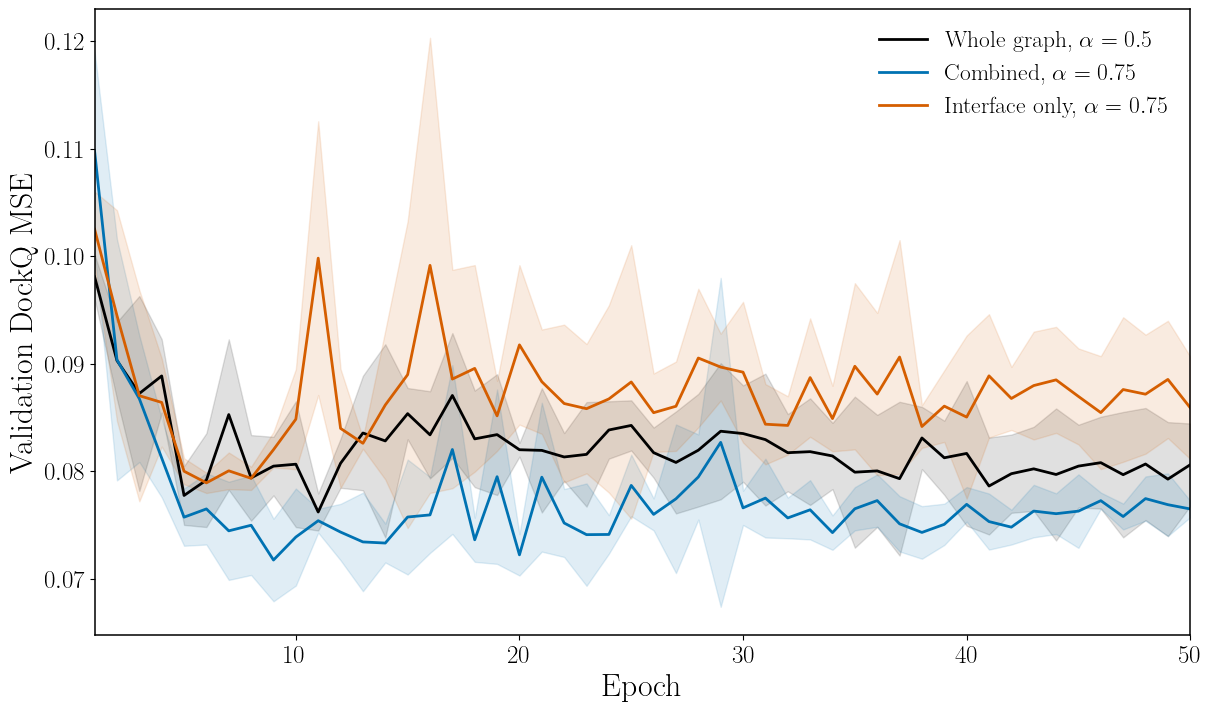

In [8]:
fig,ax=plt.subplots(figsize=(12,7),constrained_layout=True)
for pool,alpha,color in [('all',.5,'black'),(WINNER[0],WINNER[1],'#0072B2'),('interface',WINNER[1],'#D55E00')]:
    curves=[]
    for seed in SEEDS:
        if (pool,alpha)==CONTROL:
            curves.append(pd.read_csv(GATE/'dockq_priority_sweep'/f'lambda1_inverse-sqrt_seed{seed}'/'loss_history.csv').val_target_mse.to_numpy())
        else:curves.append(histories['pooling',pool,alpha,1,seed].val_target_mse.to_numpy())
    a=np.array(curves);mean=a.mean(0);sd=a.std(0,ddof=1)
    ax.plot(range(1,51),mean,color=color,lw=2,label=POOL_LABEL[pool]+rf', $\alpha={alpha:g}$')
    ax.fill_between(range(1,51),mean-sd,mean+sd,color=color,alpha=.12)
ax.set_xlabel('Epoch');ax.set_ylabel('Validation DockQ MSE');ax.set_xlim(1,50)
ax.legend(frameon=False);save(fig,'pooling_convergence')

## Interpretation

The readout below is computed from the results. Three seeds share one small validation cohort, and this cohort has now guided several sweeps. Treat the selected configuration as a candidate for confirmation on additional target-level splits. Improved MSE does not by itself prove better ranking or calibration throughout the range; the notebook reports those separately.

In [9]:
w=summary.loc[WINNER];c=summary.loc[CONTROL]
high=ranges.loc[4];tr=diag_bins.loc[('training',4)];va=diag_bins.loc[('validation',4)]
lines=[f'All 36 jobs passed completion/cohort checks; three reused controls reproduced their validation predictions.',
 f'Best pooling: {WINNER[0]}, alpha={WINNER[1]:g}. Validation MSE {w.mean_mse:.5f} +/- {w.sd_mse:.5f} (seed SD), versus {c.mean_mse:.5f} +/- {c.sd_mse:.5f}: {w.improvement_pct:.2f}% lower.',
 f'Improved in {int((selected.delta_control<0).sum())}/3 paired seeds and {int((target_comparison.delta<0).sum())}/10 validation targets.',
 f'Macro within-target Spearman: {c.macro_rho:.3f} -> {w.macro_rho:.3f}; macro-target MSE: {c.macro_mse:.5f} -> {w.macro_mse:.5f}.',
 f'Previous best, high-DockQ bin: training observed {tr.observed:.3f}, predicted {tr.predicted:.3f}; validation observed {va.observed:.3f}, predicted {va.predicted:.3f}.',
 f'Selected pooling, high-DockQ validation bin: observed {high.observed:.3f}, predicted {high.predicted:.3f}; MSE {high.mse:.4f} versus {high.control_mse:.4f}.',
 f'Fine-tuning retained epoch zero in {int((fine.selected_epoch==0).sum())}/9 runs. These runs completed 20 epochs; the fallback prevents reporting a worse checkpoint as an improvement.',
 'Combined pooling is worth confirming, but its larger graph-projector input adds parameters, so this is not a pure parameter-matched pooling ablation.',
 'No test predictions were read. Confirm on additional target-level validation splits before more extensive tuning of this same ten-target cohort.']
text='\n\n'.join(lines);(EXPORT/'readout.md').write_text(text+'\n');display(Markdown(text))

All 36 jobs passed completion/cohort checks; three reused controls reproduced their validation predictions.

Best pooling: combined, alpha=0.75. Validation MSE 0.06967 +/- 0.00167 (seed SD), versus 0.07339 +/- 0.00229: 5.06% lower.

Improved in 3/3 paired seeds and 8/10 validation targets.

Macro within-target Spearman: 0.428 -> 0.487; macro-target MSE: 0.07159 -> 0.06762.

Previous best, high-DockQ bin: training observed 0.864, predicted 0.567; validation observed 0.864, predicted 0.441.

Selected pooling, high-DockQ validation bin: observed 0.864, predicted 0.461; MSE 0.1878 versus 0.2143.

Fine-tuning retained epoch zero in 9/9 runs. These runs completed 20 epochs; the fallback prevents reporting a worse checkpoint as an improvement.

Combined pooling is worth confirming, but its larger graph-projector input adds parameters, so this is not a pure parameter-matched pooling ablation.

No test predictions were read. Confirm on additional target-level validation splits before more extensive tuning of this same ten-target cohort.